In [108]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [109]:
df = pd.read_csv("../../dataset/SP500_Historical_Data.csv")
df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,A,2000-01-03,47.07,47.18,40.27,43.04,43.04,4674353
1,A,2000-01-04,40.72,41.17,38.70,39.75,39.75,4765083
2,A,2000-01-05,39.60,39.75,36.05,37.28,37.28,5758642
3,A,2000-01-06,36.83,37.06,34.74,35.86,35.86,2534434
4,A,2000-01-07,35.30,39.41,35.27,38.85,38.85,2819626
...,...,...,...,...,...,...,...,...
2703526,ZS,2026-02-13,174.34,179.90,172.43,177.72,177.72,2434100
2703527,ZS,2026-02-17,175.82,176.85,169.61,172.59,172.59,2038100
2703528,ZS,2026-02-18,167.35,172.65,164.39,172.13,172.13,2542100
2703529,ZS,2026-02-19,169.64,172.10,166.30,168.99,168.99,3337100


## Visualize Dataset

In [110]:
tickets = df["Ticker"].unique()
print(df["Ticker"].unique())
print(df["Ticker"].nunique())
tickets

['A' 'AAL' 'AAPL' 'ABBV' 'ABNB' 'ABT' 'ACGL' 'ACN' 'ADBE' 'ADI' 'ADP'
 'AEE' 'AEP' 'AES' 'AFL' 'AIG' 'AIZ' 'AJG' 'AKAM' 'ALB' 'ALGN' 'ALL'
 'ALLE' 'AMAT' 'AMCR' 'AMD' 'AME' 'AMGN' 'AMP' 'AMT' 'AMZN' 'ANET' 'APA'
 'APD' 'APH' 'APP' 'APTV' 'ARE' 'ARES' 'ARM' 'ATO' 'AVB' 'AVGO' 'AVY'
 'AWK' 'AXON' 'AXP' 'AZO' 'BA' 'BAC' 'BALL' 'BAX' 'BBWI' 'BBY' 'BEN' 'BG'
 'BIIB' 'BIO' 'BK' 'BKNG' 'BKR' 'BLDR' 'BLK' 'BMY' 'BR' 'BRK.B' 'BRO'
 'BSX' 'BWA' 'BX' 'C' 'CAG' 'CAH' 'CARR' 'CAT' 'CB' 'CBOE' 'CBRE' 'CCI'
 'CCL' 'CDNS' 'CDW' 'CE' 'CEG' 'CF' 'CHRW' 'CHTR' 'CI' 'CINF' 'CL' 'CLX'
 'CMCSA' 'CME' 'CMG' 'CMI' 'CNC' 'CNP' 'COF' 'COIN' 'COO' 'COP' 'COST'
 'CPAY' 'CPB' 'CPRT' 'CPT' 'CRH' 'CRL' 'CRM' 'CRWD' 'CSCO' 'CSGP' 'CTAS'
 'CTRA' 'CTSH' 'CTVA' 'CVS' 'CVX' 'CZR' 'D' 'DAL' 'DASH' 'DAY' 'DD' 'DDOG'
 'DE' 'DECK' 'DELL' 'DG' 'DHI' 'DHR' 'DIS' 'DLR' 'DLTR' 'DOC' 'DOV' 'DOW'
 'DPZ' 'DRI' 'DTE' 'DUK' 'DVA' 'DVN' 'DXCM' 'EBAY' 'ECL' 'ED' 'EFX' 'EIX'
 'EL' 'EME' 'EMN' 'EMR' 'ENPH' 'EOG' 'EPAM' 'EQIX' 'EQR' 'EQT'

array(['A', 'AAL', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE',
       'ADI', 'ADP', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG',
       'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME',
       'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'APA', 'APD', 'APH', 'APP',
       'APTV', 'ARE', 'ARES', 'ARM', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK',
       'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBWI', 'BBY',
       'BEN', 'BG', 'BIIB', 'BIO', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK',
       'BMY', 'BR', 'BRK.B', 'BRO', 'BSX', 'BWA', 'BX', 'C', 'CAG', 'CAH',
       'CARR', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW',
       'CE', 'CEG', 'CF', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'CLX',
       'CMCSA', 'CME', 'CMG', 'CMI', 'CNC', 'CNP', 'COF', 'COIN', 'COO',
       'COP', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRH', 'CRL', 'CRM',
       'CRWD', 'CSCO', 'CSGP', 'CTAS', 'CTRA', 'CTSH', 'CTVA', 'CVS',
       'CVX', 'CZR', 'D', 'DAL', 'DASH', 'DAY', 'DD', 'DDOG'

### Specify the observing stock

In [111]:
def get_stock_df(df, ticker):
    stock_df = df.loc[df["Ticker"] == ticker].copy()
    stock_df["Date"] = pd.to_datetime(stock_df["Date"])
    stock_df = stock_df.sort_values("Date")
    # Set [Date] Column as Primary Key
    stock_df = stock_df.set_index("Date")
    return stock_df

In [112]:
apple_df = get_stock_df(df, "AAPL")
apple_df

,Ticker,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2000-01-03,AAPL,0.79,0.84,0.76,0.84,0.84,535796800
2000-01-04,AAPL,0.81,0.83,0.76,0.77,0.77,512377600
2000-01-05,AAPL,0.78,0.83,0.77,0.78,0.78,778321600
2000-01-06,AAPL,0.79,0.80,0.71,0.71,0.71,767972800
2000-01-07,AAPL,0.72,0.76,0.72,0.75,0.75,460734400
...,...,...,...,...,...,...,...
2026-02-13,AAPL,262.01,262.23,255.45,255.78,255.78,56290700
2026-02-17,AAPL,258.05,266.29,255.54,263.88,263.88,58469100
2026-02-18,AAPL,263.60,266.82,262.45,264.35,264.35,34203300


In [113]:
apple_last_year_df = apple_df.last("365D")
apple_last_year_df

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/536473581.py:1: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  apple_last_year_df = apple_df.last("365D")


,Ticker,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2025-02-21,AAPL,244.88,247.61,244.16,244.48,244.48,53197400
2025-02-24,AAPL,243.87,247.78,243.36,246.03,246.03,51326400
2025-02-25,AAPL,246.92,248.92,243.85,245.97,245.97,48013300
2025-02-26,AAPL,243.27,243.92,238.09,239.32,239.32,44433600
2025-02-27,AAPL,238.37,241.41,236.03,236.27,236.27,41153600
...,...,...,...,...,...,...,...
2026-02-13,AAPL,262.01,262.23,255.45,255.78,255.78,56290700
2026-02-17,AAPL,258.05,266.29,255.54,263.88,263.88,58469100
2026-02-18,AAPL,263.60,266.82,262.45,264.35,264.35,34203300


### Visualize with Candlestick Chart

In [114]:
import mplfinance as mpf

In [115]:
print(apple_last_year_df.index)

DatetimeIndex(['2025-02-21', '2025-02-24', '2025-02-25', '2025-02-26',
               '2025-02-27', '2025-02-28', '2025-03-03', '2025-03-04',
               '2025-03-05', '2025-03-06',
               ...
               '2026-02-06', '2026-02-09', '2026-02-10', '2026-02-11',
               '2026-02-12', '2026-02-13', '2026-02-17', '2026-02-18',
               '2026-02-19', '2026-02-20'],
              dtype='datetime64[ns]', name='Date', length=251, freq=None)


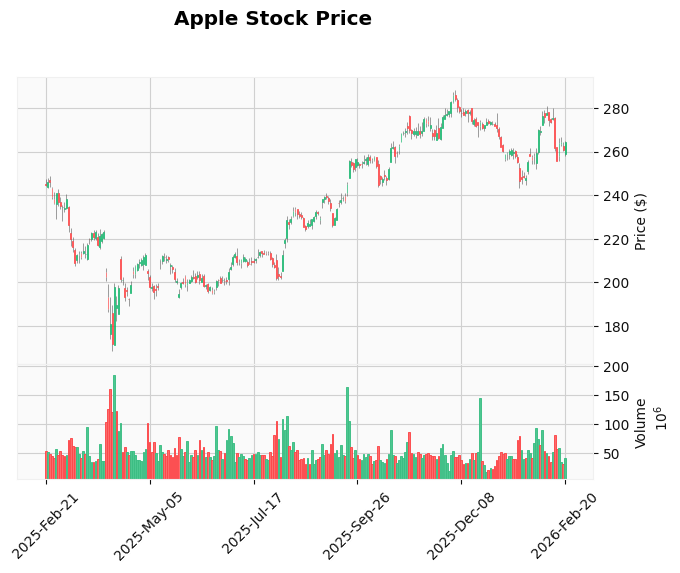

In [116]:
mpf.plot(
    apple_last_year_df,
    type="candle",
    style="yahoo",
    volume=True,
    title="Apple Stock Price",
    ylabel="Price ($)",
    ylabel_lower="Volume"
)

### Visualize with Using Simple Moving Averages (SMA20 & SMA50)

- <b>SMA20 (Simple Moving Average 20):</b> Represents the short-term market trend. Since it reacts relatively quickly to recent price movements, it is commonly used to detect short-term mommentum and potential trend reversals.
 
- <b>SMA50 (Simple Moving Average 50):</b> Represents the medium=term market trend. Compared with SMA20, it changes more slowly and is generally used to confirm the overall diection of the market.


<img src="../asset/img/005_img_AA002FAI.png" width="1000" height="200">

In [117]:
apple_last_year_df["SMA20"] = (
    apple_last_year_df["Close"]
    .rolling(window=20)
    .mean()
)

apple_last_year_df["SMA50"] = (
    apple_last_year_df["Close"]
    .rolling(window=50)
    .mean()
)

In [118]:
apple_last_year_df

,Ticker,Open,High,Low,Close,Adj Close,Volume,SMA20,SMA50
Date,,,,,,,,,
2025-02-21,AAPL,244.88,247.61,244.16,244.48,244.48,53197400,NaN,NaN
2025-02-24,AAPL,243.87,247.78,243.36,246.03,246.03,51326400,NaN,NaN
2025-02-25,AAPL,246.92,248.92,243.85,245.97,245.97,48013300,NaN,NaN
2025-02-26,AAPL,243.27,243.92,238.09,239.32,239.32,44433600,NaN,NaN
2025-02-27,AAPL,238.37,241.41,236.03,236.27,236.27,41153600,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-02-13,AAPL,262.01,262.23,255.45,255.78,255.78,56290700,262.0915,267.2506
2026-02-17,AAPL,258.05,266.29,255.54,263.88,263.88,58469100,262.5210,266.8506
2026-02-18,AAPL,263.60,266.82,262.45,264.35,264.35,34203300,263.4150,266.5288


In [119]:
# Plot SMA into the Histogram
apds = [
    mpf.make_addplot(
        apple_last_year_df["SMA20"],
        color="green",
        width=1.2
    ),
    mpf.make_addplot(
        apple_last_year_df["SMA50"],
        color="red",
        width=1.2
    )
]

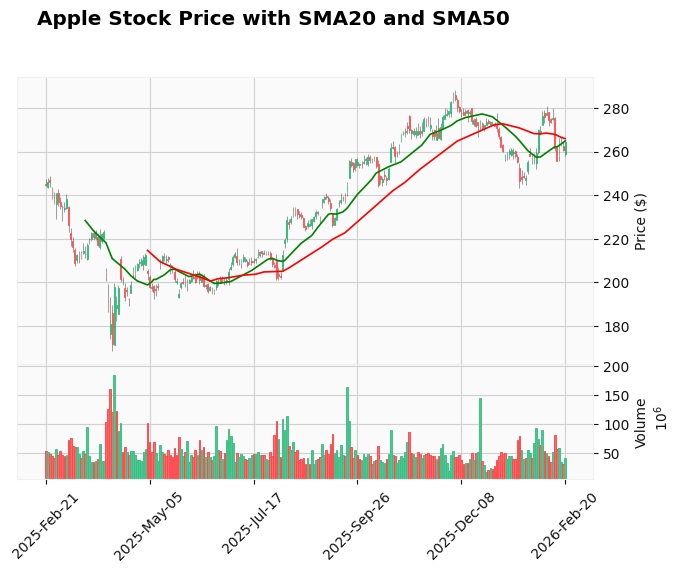

In [120]:
mpf.plot(
    apple_last_year_df,
    type="candle",
    style="yahoo",
    volume=True,
    addplot=apds,
    title="Apple Stock Price with SMA20 and SMA50",
    ylabel="Price ($)",
    ylabel_lower="Volume"
)

### Visualize with Relative Strength Index

<b>Relative Strength Index (RSI): </b> Measures the speed and magnitude of recent price movements to evaluate wheter a stock is potentially overbought or oversold.

- <b>Overbought Region: </b> [RSI > 70] : A value above 70 indicates that buying pressure has been unusually strong. Thr stock may become overbought, suggesting that a short-term price correction could occur.

- <b>Oversold Region: </b> [RSI < 30] : A value below 30 indicates excessive sellig pressure. The stock may become oversold, suggesting a potiential price rebound.

- <b>Neutral Zone: </b> [30≤RSI≤70] : The market is generally considered to be a normal trading condition without extreme momemtum.

<img src="../asset/img/006_img_AA002FAI.png" width="800" height="500">


In [121]:
import pandas_ta as ta

apple_last_year_df["RSI"] = ta.rsi(
    apple_last_year_df["Close"],
    length=14
)

apple_last_year_df

,Ticker,Open,High,Low,Close,Adj Close,Volume,SMA20,SMA50,RSI
Date,,,,,,,,,,
2025-02-21,AAPL,244.88,247.61,244.16,244.48,244.48,53197400,NaN,NaN,NaN
2025-02-24,AAPL,243.87,247.78,243.36,246.03,246.03,51326400,NaN,NaN,100.000000
2025-02-25,AAPL,246.92,248.92,243.85,245.97,245.97,48013300,NaN,NaN,99.703117
2025-02-26,AAPL,243.27,243.92,238.09,239.32,239.32,44433600,NaN,NaN,73.616615
2025-02-27,AAPL,238.37,241.41,236.03,236.27,236.27,41153600,NaN,NaN,65.191755
...,...,...,...,...,...,...,...,...,...,...
2026-02-13,AAPL,262.01,262.23,255.45,255.78,255.78,56290700,262.0915,267.2506,39.585217
2026-02-17,AAPL,258.05,266.29,255.54,263.88,263.88,58469100,262.5210,266.8506,48.606952
2026-02-18,AAPL,263.60,266.82,262.45,264.35,264.35,34203300,263.4150,266.5288,49.082085


In [122]:
apds = [

    mpf.make_addplot(
        apple_last_year_df["SMA20"],
        color="blue"
    ),

    mpf.make_addplot(
        apple_last_year_df["SMA50"],
        color="orange"
    ),

    mpf.make_addplot(
        apple_last_year_df["RSI"],
        panel=1,
        ylabel="RSI",
        color="purple"
    )

]

In [123]:
rsi70 = np.full(len(apple_last_year_df), 70)
rsi30 = np.full(len(apple_last_year_df), 30)

In [124]:
apds.extend([

    mpf.make_addplot(
        rsi70,
        panel=1,
        color="red",
        linestyle="--"
    ),

    mpf.make_addplot(
        rsi30,
        panel=1,
        color="green",
        linestyle="--"
    )

])

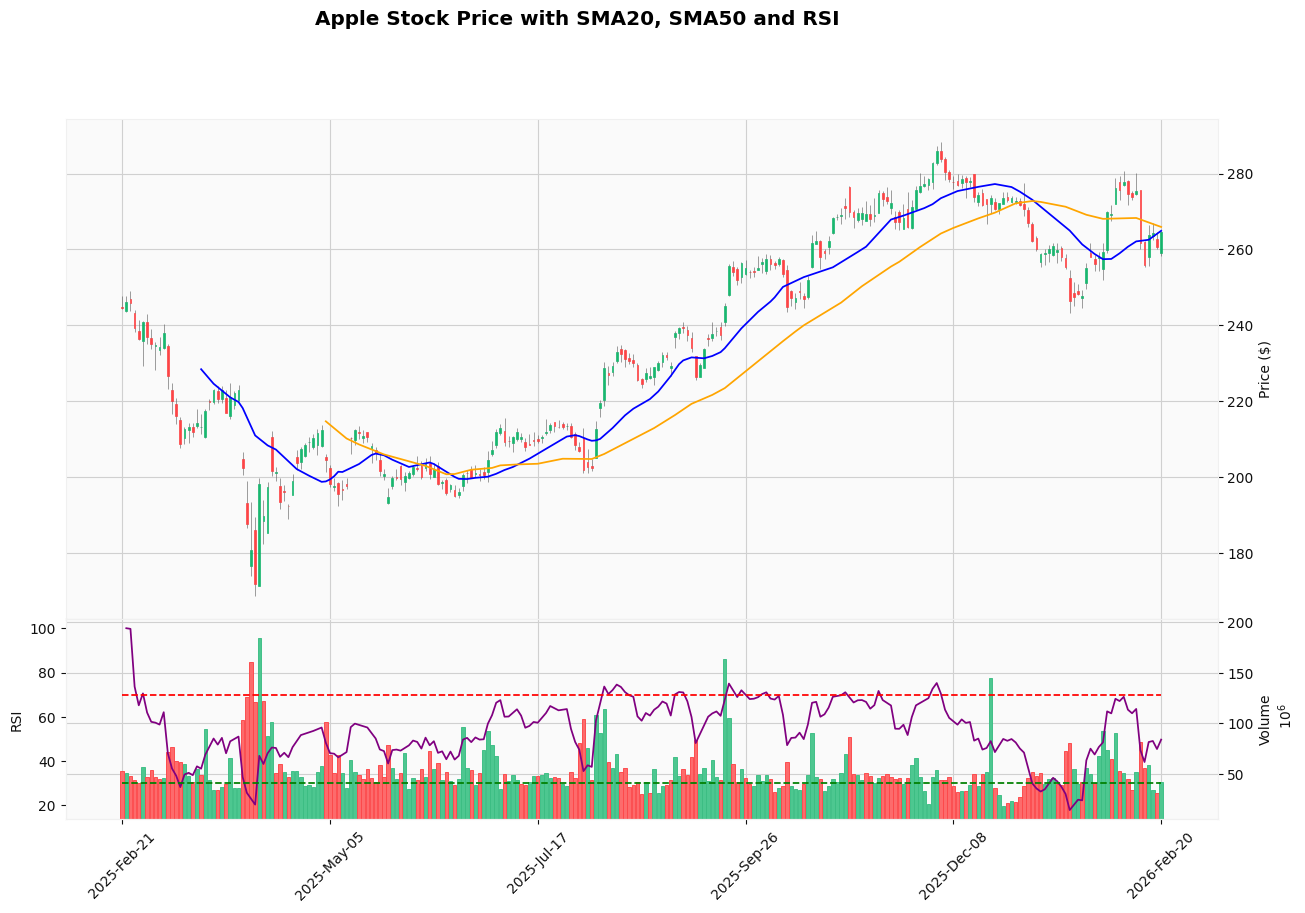

In [125]:
mpf.plot(
    apple_last_year_df,
    type="candle",
    style="yahoo",
    volume=True,
    addplot=apds,
    title="Apple Stock Price with SMA20, SMA50 and RSI",
    ylabel="Price ($)",
    ylabel_lower="Volume",
    figsize=(16,10)
)

### Visualize with Moving Average Convergence Divergence (MACD)

- <b>MACD: </b> Measures the relationship between two Exponential Moving Averages (EMAs) of a stock's closing price. Unlike SMA. the EMA assigns greater weight to recent prices, allowing it to respond more quickly to changes in market momentum.

The MACD indicator consists of three components:
- MACD Line.
- Signal Line.
- Histogram


<img src="../asset/img/007_img_AA002FAI.png" width="800" height="500">

<img src="../asset/img/008_img_AA002FAI.png" width="800" height="500">

<img src="../asset/img/009_img_AA002FAI.png" width="800" height="150">

<img src="../asset/img/010_img_AA002FAI.png" width="800" height="150">

In [126]:
macd = ta.macd(
    apple_last_year_df["Close"],
    fast=12,
    slow=26,
    signal=9
)

In [127]:
apple_last_year_df = apple_last_year_df.join(macd)
apple_last_year_df

,Ticker,Open,High,Low,Close,Adj Close,Volume,SMA20,SMA50,RSI,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
Date,,,,,,,,,,,,,
2025-02-21,AAPL,244.88,247.61,244.16,244.48,244.48,53197400,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-24,AAPL,243.87,247.78,243.36,246.03,246.03,51326400,NaN,NaN,100.000000,NaN,NaN,NaN
2025-02-25,AAPL,246.92,248.92,243.85,245.97,245.97,48013300,NaN,NaN,99.703117,NaN,NaN,NaN
2025-02-26,AAPL,243.27,243.92,238.09,239.32,239.32,44433600,NaN,NaN,73.616615,NaN,NaN,NaN
2025-02-27,AAPL,238.37,241.41,236.03,236.27,236.27,41153600,NaN,NaN,65.191755,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,AAPL,262.01,262.23,255.45,255.78,255.78,56290700,262.0915,267.2506,39.585217,1.184295,-0.012225,1.196520
2026-02-17,AAPL,258.05,266.29,255.54,263.88,263.88,58469100,262.5210,266.8506,48.606952,0.880388,-0.252906,1.133294
2026-02-18,AAPL,263.60,266.82,262.45,264.35,264.35,34203300,263.4150,266.5288,49.082085,0.669744,-0.370840,1.040584


In [128]:
apds.extend([
    mpf.make_addplot(
        apple_last_year_df["MACD_12_26_9"],
        panel=2,
        color="blue",
        ylabel="MACD"
    ),
    mpf.make_addplot(
        apple_last_year_df["MACDs_12_26_9"],
        panel=2,
        color="red"
    ),
    mpf.make_addplot(
        apple_last_year_df["MACDh_12_26_9"],
        panel=2,
        type="bar"
    )
])

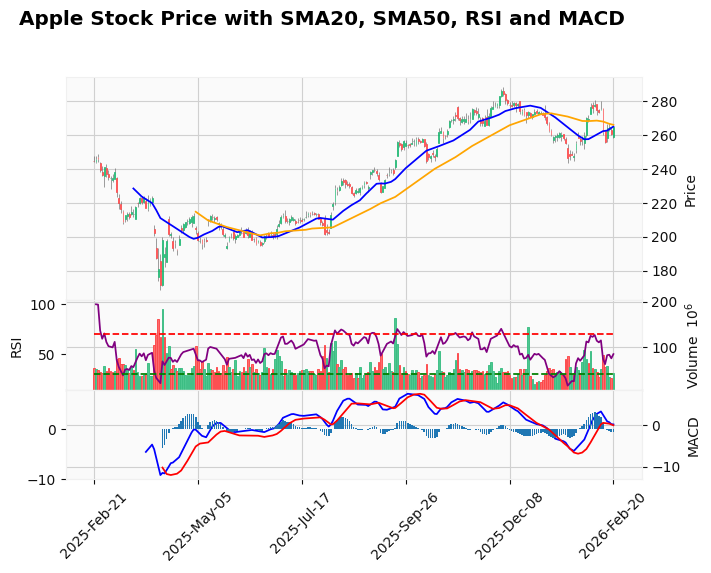

In [129]:
mpf.plot(
    apple_last_year_df,
    type="candle",
    volume=True,
    addplot=apds,
    style="yahoo",
    title="Apple Stock Price with SMA20, SMA50, RSI and MACD"
)

## Pipeline Dataset in Machine Learning

### <b>Step 1: </b> Check NAN

In [130]:
apple_last_year_df.isnull().sum()

Ticker            0
Open              0
High              0
Low               0
Close             0
Adj Close         0
Volume            0
SMA20            19
SMA50            49
RSI               1
MACD_12_26_9     25
MACDh_12_26_9    33
MACDs_12_26_9    33
dtype: int64

In [131]:
PREDICT_DAY=5

apple_last_year_df["FutureClose"] = (
    apple_last_year_df["Close"].shift(-PREDICT_DAY)
)

apple_last_year_df

,Ticker,Open,High,Low,Close,Adj Close,Volume,SMA20,SMA50,RSI,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,FutureClose
Date,,,,,,,,,,,,,,
2025-02-21,AAPL,244.88,247.61,244.16,244.48,244.48,53197400,NaN,NaN,NaN,NaN,NaN,NaN,240.79
2025-02-24,AAPL,243.87,247.78,243.36,246.03,246.03,51326400,NaN,NaN,100.000000,NaN,NaN,NaN,237.00
2025-02-25,AAPL,246.92,248.92,243.85,245.97,245.97,48013300,NaN,NaN,99.703117,NaN,NaN,NaN,234.91
2025-02-26,AAPL,243.27,243.92,238.09,239.32,239.32,44433600,NaN,NaN,73.616615,NaN,NaN,NaN,234.72
2025-02-27,AAPL,238.37,241.41,236.03,236.27,236.27,41153600,NaN,NaN,65.191755,NaN,NaN,NaN,234.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,AAPL,262.01,262.23,255.45,255.78,255.78,56290700,262.0915,267.2506,39.585217,1.184295,-0.012225,1.196520,NaN
2026-02-17,AAPL,258.05,266.29,255.54,263.88,263.88,58469100,262.5210,266.8506,48.606952,0.880388,-0.252906,1.133294,NaN
2026-02-18,AAPL,263.60,266.82,262.45,264.35,264.35,34203300,263.4150,266.5288,49.082085,0.669744,-0.370840,1.040584,NaN


In [132]:
apple_last_year_df["FutureReturn"] = (
    (
        apple_last_year_df["FutureClose"] - apple_last_year_df["Close"]
    ) / apple_last_year_df["Close"]
) * 100

In [133]:
apple_last_year_df[["Close", "FutureClose", "FutureReturn"]].head(10)

,Close,FutureClose,FutureReturn
Date,,,
2025-02-21,244.48,240.79,-1.509326
2025-02-24,246.03,237.00,-3.670284
2025-02-25,245.97,234.91,-4.496483
2025-02-26,239.32,234.72,-1.922113
2025-02-27,236.27,234.31,-0.829559
2025-02-28,240.79,238.03,-1.146227
2025-03-03,237.00,226.49,-4.434599
2025-03-04,234.91,219.88,-6.398195
2025-03-05,234.72,216.04,-7.958419


In [134]:
def create_label(future_return):
    if future_return > 3:
        return 1 #Buy
    elif future_return < -3:
        return -1 #Sell
    else:
        return 0 #Watch

In [135]:
apple_last_year_df["Label"] = (
    apple_last_year_df["FutureReturn"].apply(create_label)
)

In [136]:
apple_last_year_df[
    ["FutureReturn", "Label"]
].head(10)

,FutureReturn,Label
Date,,
2025-02-21,-1.509326,0
2025-02-24,-3.670284,-1
2025-02-25,-4.496483,-1
2025-02-26,-1.922113,0
2025-02-27,-0.829559,0
2025-02-28,-1.146227,0
2025-03-03,-4.434599,-1
2025-03-04,-6.398195,-1
2025-03-05,-7.958419,-1


### <b>Step 2:</b> Remove NAN

In [137]:
apple_last_year_df = apple_last_year_df.dropna()
apple_last_year_df

,Ticker,Open,High,Low,Close,Adj Close,Volume,SMA20,SMA50,RSI,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,FutureClose,FutureReturn,Label
Date,,,,,,,,,,,,,,,,
2025-05-02,AAPL,205.20,206.09,201.28,204.46,204.46,101010600,198.7960,214.6540,48.321269,-1.132479,2.379286,-3.511765,197.67,-3.320943,-1
2025-05-05,AAPL,202.22,203.21,197.35,198.03,198.03,69018500,199.3195,213.7250,43.598200,-1.672888,1.471102,-3.143989,210.15,6.120285,1
2025-05-06,AAPL,197.35,199.78,196.17,197.65,197.65,51216500,200.1685,212.7574,43.328663,-2.107534,0.829164,-2.936698,212.28,7.401973,1
2025-05-07,AAPL,198.31,198.57,192.41,195.40,195.40,68536700,201.3550,211.7460,41.685362,-2.603539,0.266528,-2.870066,211.69,8.336745,1
2025-05-08,AAPL,196.86,199.18,193.84,196.63,196.63,50478900,201.2870,210.8922,42.958972,-2.864357,0.004568,-2.868925,210.81,7.211514,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-06,AAPL,276.86,280.65,276.67,277.86,277.86,50453400,259.9080,268.4514,69.024196,2.206734,3.305937,-1.099203,255.78,-7.946448,-1
2026-02-09,AAPL,277.91,278.20,271.70,274.62,274.62,44623400,260.6825,268.4096,63.217421,2.680129,3.023466,-0.343337,263.88,-3.910859,-1
2026-02-10,AAPL,274.89,275.37,272.94,273.68,273.68,34376900,261.3660,268.3374,61.598335,2.945495,2.631065,0.314430,264.35,-3.409091,-1


In [138]:
apple_last_year_df.isnull().sum()

Ticker           0
Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
SMA20            0
SMA50            0
RSI              0
MACD_12_26_9     0
MACDh_12_26_9    0
MACDs_12_26_9    0
FutureClose      0
FutureReturn     0
Label            0
dtype: int64

In [139]:
apple_last_year_df["Label"].value_counts()
apple_last_year_df

,Ticker,Open,High,Low,Close,Adj Close,Volume,SMA20,SMA50,RSI,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,FutureClose,FutureReturn,Label
Date,,,,,,,,,,,,,,,,
2025-05-02,AAPL,205.20,206.09,201.28,204.46,204.46,101010600,198.7960,214.6540,48.321269,-1.132479,2.379286,-3.511765,197.67,-3.320943,-1
2025-05-05,AAPL,202.22,203.21,197.35,198.03,198.03,69018500,199.3195,213.7250,43.598200,-1.672888,1.471102,-3.143989,210.15,6.120285,1
2025-05-06,AAPL,197.35,199.78,196.17,197.65,197.65,51216500,200.1685,212.7574,43.328663,-2.107534,0.829164,-2.936698,212.28,7.401973,1
2025-05-07,AAPL,198.31,198.57,192.41,195.40,195.40,68536700,201.3550,211.7460,41.685362,-2.603539,0.266528,-2.870066,211.69,8.336745,1
2025-05-08,AAPL,196.86,199.18,193.84,196.63,196.63,50478900,201.2870,210.8922,42.958972,-2.864357,0.004568,-2.868925,210.81,7.211514,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-06,AAPL,276.86,280.65,276.67,277.86,277.86,50453400,259.9080,268.4514,69.024196,2.206734,3.305937,-1.099203,255.78,-7.946448,-1
2026-02-09,AAPL,277.91,278.20,271.70,274.62,274.62,44623400,260.6825,268.4096,63.217421,2.680129,3.023466,-0.343337,263.88,-3.910859,-1
2026-02-10,AAPL,274.89,275.37,272.94,273.68,273.68,34376900,261.3660,268.3374,61.598335,2.945495,2.631065,0.314430,264.35,-3.409091,-1


In [140]:
FEATURES = [
    "SMA20",
    "SMA50",
    "RSI",
    "MACD_12_26_9",
    "MACDs_12_26_9",
    "MACDh_12_26_9",
    "Volume"
]

In [147]:
X = apple_last_year_df[FEATURES]
y = apple_last_year_df["Label"]
print(X.shape)
print(y.shape)
X.describe()

(197, 7)
(197,)


,SMA20,SMA50,RSI,MACD_12_26_9,MACDs_12_26_9,MACDh_12_26_9,Volume
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,1.970000e+02
mean,236.714619,232.657819,55.667860,1.999297,1.891557,0.107739,5.221260e+07
std,28.313631,27.064801,12.499207,3.358685,3.231568,1.116884,1.979399e+07
min,198.796000,200.594800,17.904542,-6.237251,-4.958821,-1.922411,1.791060e+07
25%,206.029000,205.379000,47.129561,-0.986635,-1.136428,-0.693969,4.128800e+07
50%,236.699000,225.223000,57.675847,2.479482,2.176573,0.016345,4.726580e+07
75%,262.522000,263.576800,66.348007,4.839266,4.775491,0.726913,5.562620e+07
max,277.254500,272.746400,75.246578,7.534635,7.018706,3.305937,1.637413e+08


Label
-1     33
 0    113
 1     51
Name: count, dtype: int64


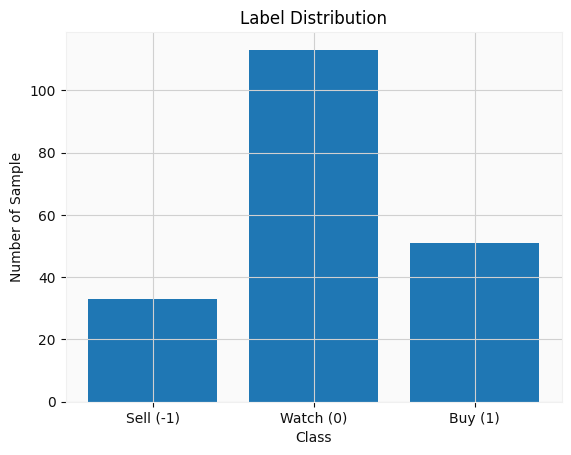

In [ ]:
label_counts = y.value_counts().sort_index()
print(label_counts)
plt.bar(
    ["Sell (-1)", "Watch (0)", "Buy (1)"],
    label_counts.values
)
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Sample")
plt.show()

### <b>Step 3:</b> Train/Test Split

In [158]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape)
print(y_train.shape)

(157, 7)
(157,)


### <b>Step 4: </b> Standardization (Z-score Normalization)

In [159]:
X_train_scaled = X_train.copy()
statistics = {}

In [160]:
for feature in FEATURES:
    mean = X_train[feature].mean()
    std = X_train[feature].std(ddof=0)
    statistics[feature] = (mean, std)
    X_train_scaled[feature] = (
        X_train_scaled[feature] - mean
    ) / std


In [ ]:
X_train_scaled

### <b>Step 5: </b> PCA (2 Components)

<div>Computing Covariance Matrix</div>
      ↓
<div>Visualize Covariance Matrix</div>
      ↓
<div>Eigenvalue and Eigenvector</div>
      ↓
<div>Sorting Eigenvalue</div>
      ↓
<div>Choosing 2 Principal Components</div>
      ↓
<div>Project data on new axis</div>
      ↓
<div>Visualize with PCA</div>

In [161]:
cov_matrix = np.cov(
    X_train_scaled,
    rowvar=False
)

In [162]:
print(cov_matrix.shape)

(7, 7)


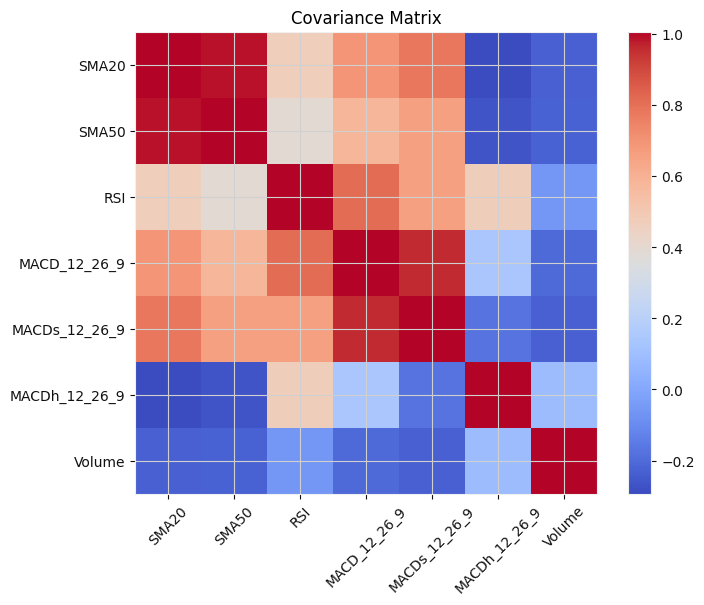

In [163]:
plt.figure(figsize=(8,6))

plt.imshow(
    cov_matrix,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(FEATURES)),
    FEATURES,
    rotation=45
)

plt.yticks(
    range(len(FEATURES)),
    FEATURES
)

plt.title("Covariance Matrix")

plt.show()

In [166]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [167]:
for i, value in enumerate(eigenvalues):
    print(f"PC{i}: {value:.4f}")

PC0: 3.8898
PC1: 1.5927
PC2: 0.9213
PC3: 0.5026
PC4: 0.1359
PC5: 0.0026
PC6: -0.0000


In [168]:
for i in range(len(eigenvalues)):
    print(f"\Eigenvector {i + 1}")
    print(eigenvectors[:, i])

\Eigenvector 1
[ 0.46253628  0.42559189  0.369199    0.46755821  0.47620144 -0.03632143
 -0.14807467]
\Eigenvector 2
[ 0.24621928  0.27250021 -0.49621222 -0.22296084  0.00615717 -0.73008989
 -0.19003275]
\Eigenvector 3
[-0.13295283 -0.12665541 -0.01503564  0.00905731 -0.04305873  0.16683741
 -0.96761825]
\Eigenvector 4
[ 0.34481873  0.57731991 -0.0163193  -0.34006644 -0.47844924  0.44971675
 -0.0270448 ]
\Eigenvector 5
[-0.02599354 -0.04393273  0.78482318 -0.37061234 -0.23454804 -0.42917823
 -0.06990409]
\Eigenvector 6
[ 0.76693166 -0.6271724  -0.03202686 -0.06849818 -0.08947304  0.06847685
 -0.00764013]
\Eigenvector 7
[ 4.85308170e-14 -3.92402752e-14 -2.85193241e-15  6.88407622e-01
 -6.92393200e-01 -2.16070828e-01 -5.17501085e-16]


<>:2: SyntaxWarning: invalid escape sequence '\E'
<>:2: SyntaxWarning: invalid escape sequence '\E'
/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/2719511803.py:2: SyntaxWarning: invalid escape sequence '\E'
  print(f"\Eigenvector {i + 1}")


In [169]:
idx = np.argsort(eigenvalues)[::-1]
idx

array([0, 1, 2, 3, 4, 5, 6])

In [ ]:
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

W = eigenvectors[:, :2]

(7, 2)

### Compute Principle Component Analysis (PCA)

In [176]:
X_train_pca = np.dot(X_train_scaled, W)

In [189]:
print(X_train_pca.shape)

(157, 2)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


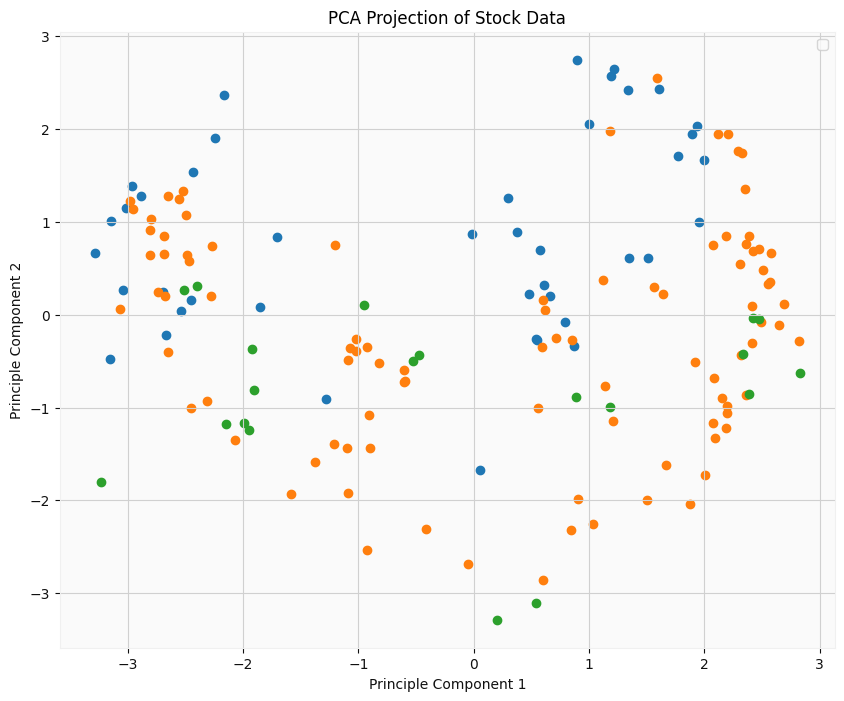

In [184]:
plt.figure(figsize=(10, 8))

buy = y_train == 1
watch = y_train == 0
sell = y_train == -1

plt.scatter(
    X_train_pca[buy, 0],
    X_train_pca[buy, 1]
)

plt.scatter(
    X_train_pca[watch, 0],
    X_train_pca[watch, 1]
)

plt.scatter(
    X_train_pca[sell, 0],
    X_train_pca[sell, 1]
)

plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")

plt.title("PCA Projection of Stock Data")

plt.legend()

plt.grid(True)

plt.show()


In [194]:
print(X_train_pca.shape)

(157, 2)


### <b>Step 6:</b> Compute Kernel Matrix 

<div>Dataset</div>
      ↓
<div>StandardScaler</div>
      ↓
<div>Compute Kernel Matrix</div>
      ↓
<div>Construct Q Matrix</div>
      ↓
<div>Solve Quadratic Programming</div>
      ↓
<div>Find α (Lagrange Multipliers)</div>
      ↓
<div>Find Support Vectors</div>
      ↓
<div>Compute Bias b</div>
      ↓
<div>Prediction</div>

In [204]:
gamma = 0.5
n = X_train_scaled.shape[0]

#Initial Kernel Matrix
K = np.zeros((n, n))
X_numpy = X_train_scaled.to_numpy()

for i in range(n):
    for j in range(n):
        distance = np.sum(
            (X_numpy[i] - X_numpy[j]) ** 2
        )
        K[i, j] = np.exp(-gamma * distance)

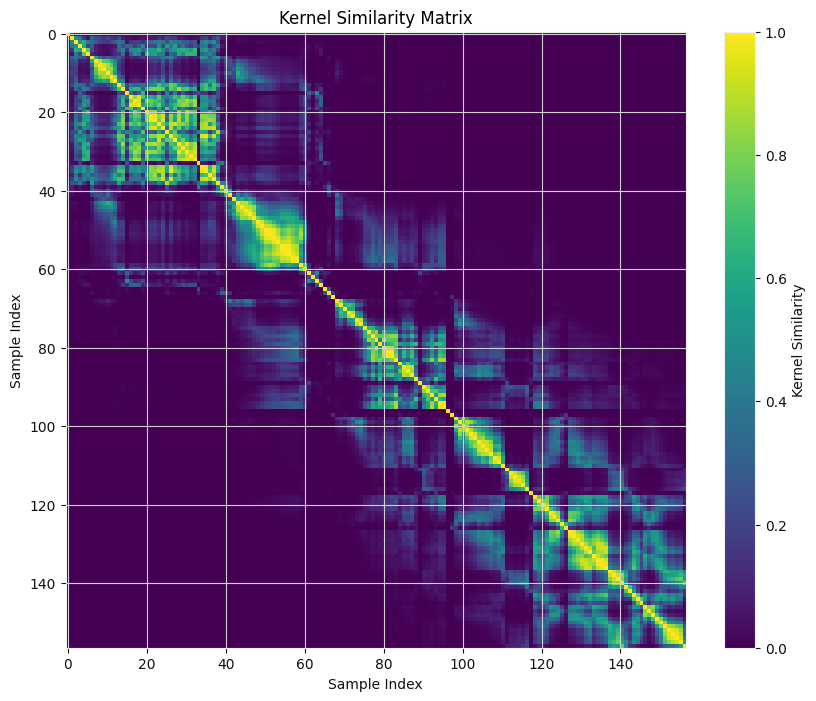

In [206]:
#Visualize Kernel Matrix with Heatmap

plt.figure(figsize=(10,8))

plt.imshow(
    K,
    cmap="viridis",
    aspect="auto"
)

plt.colorbar(label="Kernel Similarity")

plt.xlabel("Sample Index")
plt.ylabel("Sample Index")

plt.title("Kernel Similarity Matrix")
plt.show()

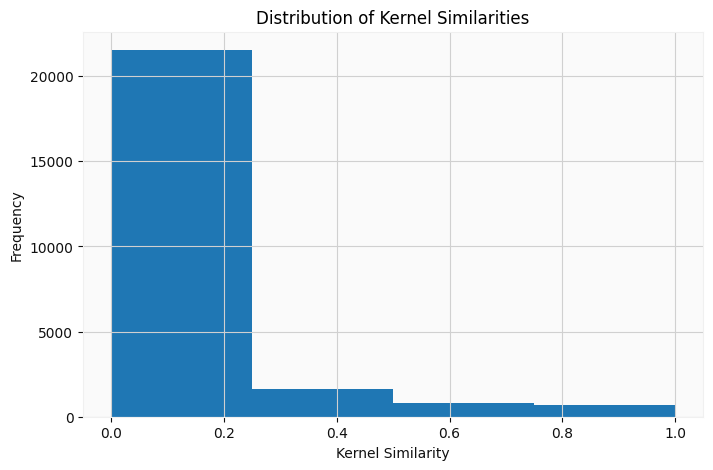

In [208]:
#Visualize Historygram

plt.figure(figsize=(8,5))

plt.hist(
    K.flatten(),
    bins=4
)

plt.xlabel("Kernel Similarity")

plt.ylabel("Frequency")

plt.title("Distribution of Kernel Similarities")

plt.show()